# Show class distribution after applying SMOTE to the train data

## Import .npy data

Only the label arrays are needed for the class distribution. The train labels in `y_train.npy` are SMOTE-balanced (see `main.py`); validation and test keep their natural distribution.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path("../data/preprocessed")

# Wrap each label array in a DataFrame with a 'diagnosis' column so the chart
# code below is identical to data_exploration.ipynb.
train_df = pd.DataFrame({"diagnosis": np.load(DATA_DIR / "y_train.npy")})
val_df = pd.DataFrame({"diagnosis": np.load(DATA_DIR / "y_val.npy")})
test_df = pd.DataFrame({"diagnosis": np.load(DATA_DIR / "y_test.npy")})

splits = {"Train": train_df, "Validation": val_df, "Test": test_df}

## Visualize the class distribution

The `diagnosis` grade follows the standard APTOS / diabetic-retinopathy scale:

| Grade | Class |
|-------|-------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

                  Train  Validation  Test
No DR              1434         172   199
Mild               1434          40    30
Moderate           1434         104    87
Severe             1434          22    17
Proliferative DR   1434          28    33


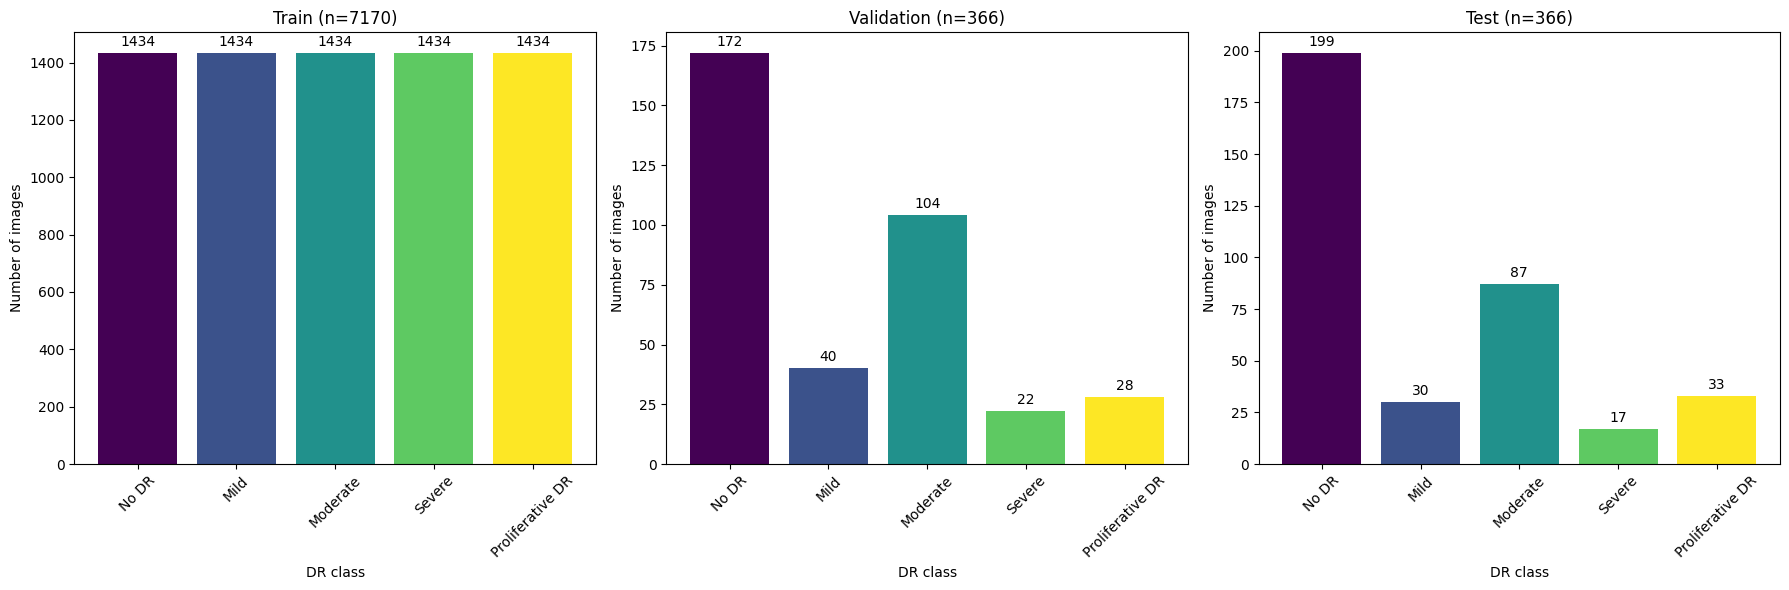

In [2]:
import matplotlib.pyplot as plt

class_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}
classes = list(class_names.keys())

# Count per class for every split (reindex so missing classes show as 0)
dist = pd.DataFrame(
    {name: df["diagnosis"].value_counts().reindex(classes, fill_value=0)
     for name, df in splits.items()}
)
dist.index = [class_names[c] for c in dist.index]
print(dist)

# One subplot per split
fig, axes = plt.subplots(1, len(splits), figsize=(18, 6))
for ax, name in zip(axes, splits):
    bars = ax.bar(dist.index, dist[name], color=plt.cm.viridis(
        [i / (len(classes) - 1) for i in range(len(classes))]))
    ax.set_title(f"{name} (n={dist[name].sum()})")
    ax.set_xlabel("DR class")
    ax.set_ylabel("Number of images")
    ax.bar_label(bars, padding=3)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()